# Hybrid Lorentz-ParT MAE for JetClass
This notebook builds a GSoC 2026 jet classification workflow with MAE pretraining.

## 1. Motivation
Jet tagging requires models that capture both particle interactions and Lorentz-aware structure.
This pipeline combines ParT and Lorentz-inspired blocks, then fine-tunes after MAE pretraining.

## 2. Setup
Imports, reproducibility settings, and runtime configuration are initialized here.

In [1]:
import os, math, time, json, random, warnings, copy
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)

try:
    import uproot
    import awkward as ak
    HAS_ROOT = True
except ImportError:
    HAS_ROOT = False


In [2]:
@dataclass
class Config:
    DATA_ROOT: str = '../datasets/JetClass'
    MAX_PARTICLES: int = 128
    NUM_CLASSES: int = 10

    BATCH_SIZE: int = 16
    NUM_WORKERS: int = 0
    PRETRAIN_EPOCHS: int = 12
    FINETUNE_EPOCHS: int = 20
    LEARNING_RATE: float = 2e-4
    WEIGHT_DECAY: float = 1e-4
    MASK_RATIO: float = 0.4

                                                                          
    WARMUP_EPOCHS: int = 2                                             
    LABEL_SMOOTHING: float = 0.1                                   
    USE_BIASED_MASK: bool = True                                           
    BACKBONE_LR_FACTOR: float = 0.1                                      

    USE_AUX_MASS: bool = False
    USE_CLASS_WEIGHTS: bool = True
    USE_MIXED_PRECISION: bool = True
    QUICK_DEMO_MODE: bool = False
    QUICK_MAX_EVENTS_PER_FILE: int = 1000
    FULL_MAX_EVENTS_PER_FILE: Optional[int] = 2500

    SAMPLE_SIZE_LIMIT: int = 100000
    ENFORCE_STRICT_100K_WHEN_AVAILABLE: bool = True
    SAMPLING_SEED: Optional[int] = 42

    NUM_TRAIN_FILES: Optional[int] = None
    NUM_VAL_FILES: Optional[int] = None
    NUM_TEST_FILES: Optional[int] = None

    PER_PARTICLE_FEATURES: Tuple[str, ...] = (
        'px','py','pz','E','pt','eta','phi','charge','valid_mask'
    )
    PAIRWISE_FEATURES: Tuple[str, ...] = ('lnDelta','lnkT','lnz','lnm2')
    SCALE_FEATURES: Tuple[str, ...] = ('charge',)

    EMBED_DIM: int = 128
    NUM_HEADS: int = 8
    NUM_LAYERS_PART: int = 4
    NUM_LAYERS_LORENTZ: int = 3
    MLP_RATIO: float = 4.0
    DROPOUT: float = 0.1
    USE_TOKEN_GATE: bool = True
    USE_EVENT_GATE: bool = True

    W_RECO: float = 1.0
    W_CONS: float = 0.2
    W_CLASS: float = 1.0
    AUX_MASS_WEIGHT: float = 0.2

    GRAD_CLIP_NORM: float = 1.0
    EARLY_STOP_PATIENCE: int = 5
    SEED: int = 42

                                                                          
    SIGNAL_EFF_STANDARD: float = 0.50                             
    SIGNAL_EFF_HIGH:     float = 0.99                                    

cfg = Config()
cfg


Config(DATA_ROOT='../datasets/JetClass', MAX_PARTICLES=128, NUM_CLASSES=10, BATCH_SIZE=16, NUM_WORKERS=0, PRETRAIN_EPOCHS=12, FINETUNE_EPOCHS=20, LEARNING_RATE=0.0002, WEIGHT_DECAY=0.0001, MASK_RATIO=0.4, WARMUP_EPOCHS=2, LABEL_SMOOTHING=0.1, USE_BIASED_MASK=True, BACKBONE_LR_FACTOR=0.1, USE_AUX_MASS=False, USE_CLASS_WEIGHTS=True, USE_MIXED_PRECISION=True, QUICK_DEMO_MODE=False, QUICK_MAX_EVENTS_PER_FILE=1000, FULL_MAX_EVENTS_PER_FILE=2500, SAMPLE_SIZE_LIMIT=100000, ENFORCE_STRICT_100K_WHEN_AVAILABLE=True, SAMPLING_SEED=42, NUM_TRAIN_FILES=None, NUM_VAL_FILES=None, NUM_TEST_FILES=None, PER_PARTICLE_FEATURES=('px', 'py', 'pz', 'E', 'pt', 'eta', 'phi', 'charge', 'valid_mask'), PAIRWISE_FEATURES=('lnDelta', 'lnkT', 'lnz', 'lnm2'), SCALE_FEATURES=('charge',), EMBED_DIM=128, NUM_HEADS=8, NUM_LAYERS_PART=4, NUM_LAYERS_LORENTZ=3, MLP_RATIO=4.0, DROPOUT=0.1, USE_TOKEN_GATE=True, USE_EVENT_GATE=True, W_RECO=1.0, W_CONS=0.2, W_CLASS=1.0, AUX_MASS_WEIGHT=0.2, GRAD_CLIP_NORM=1.0, EARLY_STOP_PATIEN

In [3]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(cfg.SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
amp_enabled = cfg.USE_MIXED_PRECISION and device.type == 'cuda'
print('Device:', device)
print('Mixed precision:', amp_enabled)
print('ROOT stack available:', HAS_ROOT)


Device: cuda
Mixed precision: True
ROOT stack available: True


## 3. Data Understanding
We inspect class distribution and important particle-level properties before training.

In [4]:
def resolve_data_root(user_path: str) -> Path:
    raw = Path(user_path)
    candidates = [
        raw,
        Path.cwd() / raw,
        Path.cwd().parent / raw,
        Path.cwd() / 'datasets' / 'JetClass',
        Path.cwd().parent / 'datasets' / 'JetClass',
    ]

    seen = set()
    for candidate in candidates:
        rp = candidate.resolve()
        if rp in seen:
            continue
        seen.add(rp)
        if rp.exists() and rp.is_dir():
            return rp

    tried = '\n'.join([f' - {c.resolve()}' for c in candidates])
    raise FileNotFoundError('Could not locate JetClass data root. Tried:\n' + tried)

def discover_root_files(data_root: Path) -> List[Path]:
    return sorted(data_root.rglob('*.root')) if data_root.exists() else []

def infer_class_name(path: Path) -> str:
    return path.stem.split('_')[0]

data_root = resolve_data_root(cfg.DATA_ROOT)
cfg.DATA_ROOT = str(data_root)
files = discover_root_files(data_root)
print('CWD:', Path.cwd())
print('Data root:', data_root.resolve())
print('ROOT files found:', len(files))
for p in files[:8]:
    print(' -', p.name)

classes = sorted({infer_class_name(p) for p in files}) if files else []
print('Inferred classes:', classes)


CWD: C:\Users\Rahul\Desktop\AA Gsoc'26 p-3\notebook
Data root: C:\Users\Rahul\Desktop\AA Gsoc'26 p-3\datasets\JetClass
ROOT files found: 100
 - HToBB_000.root
 - HToBB_001.root
 - HToBB_002.root
 - HToBB_003.root
 - HToBB_004.root
 - HToBB_005.root
 - HToBB_006.root
 - HToBB_007.root
Inferred classes: ['HToBB', 'HToCC', 'HToGG', 'HToWW2Q1L', 'HToWW4Q', 'TTBar', 'TTBarLep', 'WToQQ', 'ZJetsToNuNu', 'ZToQQ']


In [5]:
BRANCH_CANDIDATES = {
    'px': ['part_px','px','PFCands_px','particle_px'],
    'py': ['part_py','py','PFCands_py','particle_py'],
    'pz': ['part_pz','pz','PFCands_pz','particle_pz'],
    'E': ['part_energy','part_e','energy','E','PFCands_energy','particle_e'],
    'pt': ['part_pt','pt','PFCands_pt','particle_pt'],
    'eta': ['part_eta','eta','PFCands_eta','particle_eta'],
    'phi': ['part_phi','phi','PFCands_phi','particle_phi'],
    'charge': ['part_charge','charge','PFCands_charge','particle_charge'],
}

def resolve_branches(available: List[str], candidates: Dict[str, List[str]]) -> Dict[str, Optional[str]]:
    lower = {a.lower(): a for a in available}
    out = {}
    for k, opts in candidates.items():
        hit = None
        for o in opts:
            if o in available:
                hit = o
                break
            if o.lower() in lower:
                hit = lower[o.lower()]
                break
        out[k] = hit
    return out

if HAS_ROOT and files:
    with uproot.open(files[0]) as f:
        tree_name = None
        for c in ['tree','events','Events','JetTree']:
            if c in f:
                tree_name = c
                break
        if tree_name is None:
            for k in f.keys():
                if hasattr(f[k], 'keys'):
                    tree_name = k
                    break
        print('Selected tree:', tree_name)
        branches = [str(b) for b in f[tree_name].keys()]
        print('First branches:', branches[:30])
        print('Resolved map:', resolve_branches(branches, BRANCH_CANDIDATES))
else:
    print('No ROOT file available for branch inspection.')


Selected tree: tree
First branches: ['part_px', 'part_py', 'part_pz', 'part_energy', 'part_deta', 'part_dphi', 'part_d0val', 'part_d0err', 'part_dzval', 'part_dzerr', 'part_charge', 'part_isChargedHadron', 'part_isNeutralHadron', 'part_isPhoton', 'part_isElectron', 'part_isMuon', 'label_QCD', 'label_Hbb', 'label_Hcc', 'label_Hgg', 'label_H4q', 'label_Hqql', 'label_Zqq', 'label_Wqq', 'label_Tbqq', 'label_Tbl', 'jet_pt', 'jet_eta', 'jet_phi', 'jet_energy']
Resolved map: {'px': 'part_px', 'py': 'part_py', 'pz': 'part_pz', 'E': 'part_energy', 'pt': None, 'eta': None, 'phi': None, 'charge': 'part_charge'}


## 4. ROOT Data Loading
JetClass ROOT files are loaded and transformed into model-ready arrays.

In [6]:
def safe_eta(px: np.ndarray, py: np.ndarray, pz: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    p = np.sqrt(px**2 + py**2 + pz**2 + eps)
    ratio = np.clip(pz / np.maximum(p, eps), -1.0 + 1e-6, 1.0 - 1e-6)
    return np.arctanh(ratio).astype(np.float32)

def _safe_event_arrays(arr_list: List[Any], dtype=np.float32) -> List[np.ndarray]:
    out = []
    for arr in arr_list:
        a = np.asarray(arr, dtype=dtype)
        out.append(np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0))
    return out

def read_jetclass_root(file_path: Path, max_events: Optional[int]) -> List[Dict[str, np.ndarray]]:
    if not HAS_ROOT:
        raise RuntimeError('uproot/awkward not installed.')

    events = []
    with uproot.open(file_path) as f:
        tree_name = None
        for c in ['tree','events','Events','JetTree']:
            if c in f:
                tree_name = c
                break
        if tree_name is None:
            for k in f.keys():
                if hasattr(f[k], 'arrays'):
                    tree_name = k
                    break
        tree = f[tree_name]
        av = [str(x) for x in tree.keys()]
        bm = resolve_branches(av, BRANCH_CANDIDATES)

        has_cartesian = bm['px'] is not None and bm['py'] is not None and bm['pz'] is not None
        has_cyl = bm['pt'] is not None and bm['eta'] is not None and bm['phi'] is not None
        if not (has_cartesian or has_cyl):
            raise ValueError(f'Missing required momentum branches in {file_path.name}; need either (px,py,pz) or (pt,eta,phi).')

        read_keys = [v for v in bm.values() if v is not None]
        arrs = tree.arrays(read_keys, library='ak', entry_stop=max_events)

        if has_cartesian:
            pxL = _safe_event_arrays(ak.to_list(arrs[bm['px']]))
            pyL = _safe_event_arrays(ak.to_list(arrs[bm['py']]))
            pzL = _safe_event_arrays(ak.to_list(arrs[bm['pz']]))
            ptL = [np.sqrt(px**2 + py**2 + 1e-8).astype(np.float32) for px, py in zip(pxL, pyL)]
            etaL = [safe_eta(px, py, pz).astype(np.float32) for px, py, pz in zip(pxL, pyL, pzL)]
            phiL = [np.arctan2(py, px).astype(np.float32) for py, px in zip(pyL, pxL)]
        else:
            ptL = _safe_event_arrays(ak.to_list(arrs[bm['pt']]))
            etaL = _safe_event_arrays(ak.to_list(arrs[bm['eta']]))
            phiL = _safe_event_arrays(ak.to_list(arrs[bm['phi']]))
            pxL = [(pt * np.cos(phi)).astype(np.float32) for pt, phi in zip(ptL, phiL)]
            pyL = [(pt * np.sin(phi)).astype(np.float32) for pt, phi in zip(ptL, phiL)]
            pzL = [(pt * np.sinh(eta)).astype(np.float32) for pt, eta in zip(ptL, etaL)]

        if bm['E'] is not None:
            EL = _safe_event_arrays(ak.to_list(arrs[bm['E']]))
        else:
            EL = [np.sqrt(px**2 + py**2 + pz**2 + 1e-8).astype(np.float32) for px, py, pz in zip(pxL, pyL, pzL)]

        if bm['charge'] is not None:
            qL = _safe_event_arrays(ak.to_list(arrs[bm['charge']]))
        else:
            qL = [np.zeros_like(px, dtype=np.float32) for px in pxL]

        for px, py, pz, E, pt, eta, phi, q in zip(pxL, pyL, pzL, EL, ptL, etaL, phiL, qL):
            n = min(len(px), len(py), len(pz), len(E), len(pt), len(eta), len(phi), len(q))
            if n == 0:
                continue
            events.append({
                'px': px[:n], 'py': py[:n], 'pz': pz[:n], 'E': E[:n],
                'pt': pt[:n], 'eta': eta[:n], 'phi': phi[:n],
                'charge': q[:n], 'valid_mask': np.ones(n, dtype=np.float32)
            })
    return events

def pad_event(ev: Dict[str,np.ndarray], max_particles: int, feat_order: Tuple[str,...]):
    x = np.zeros((max_particles, len(feat_order)), dtype=np.float32)
    mask = np.zeros((max_particles,), dtype=np.float32)
    p4 = np.zeros((max_particles, 4), dtype=np.float32)

    n = min(len(ev['px']), max_particles)
    mask[:n] = 1.0

    for j, name in enumerate(feat_order):
        arr = np.nan_to_num(ev.get(name, np.zeros_like(ev['px'])), nan=0.0, posinf=0.0, neginf=0.0)
        x[:n, j] = arr[:n]

    p4[:n, 0] = np.nan_to_num(ev['E'][:n], nan=0.0, posinf=0.0, neginf=0.0)
    p4[:n, 1] = np.nan_to_num(ev['px'][:n], nan=0.0, posinf=0.0, neginf=0.0)
    p4[:n, 2] = np.nan_to_num(ev['py'][:n], nan=0.0, posinf=0.0, neginf=0.0)
    p4[:n, 3] = np.nan_to_num(ev['pz'][:n], nan=0.0, posinf=0.0, neginf=0.0)
    return x, mask, p4

def event_mass(p4: np.ndarray, mask: np.ndarray) -> float:
    vv = p4[mask > 0.5]
    if vv.size == 0:
        return 0.0
    s = vv.sum(axis=0)
    m2 = s[0]**2 - (s[1]**2 + s[2]**2 + s[3]**2)
    return float(np.sqrt(max(m2, 0.0)))


In [7]:
class JetClassDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, mask, p4, y, mass = self.samples[idx]
        return {
            'x': torch.tensor(x, dtype=torch.float32),
            'mask': torch.tensor(mask, dtype=torch.float32),
            'p4': torch.tensor(p4, dtype=torch.float32),
            'y': torch.tensor(y, dtype=torch.long),
            'mass': torch.tensor(mass, dtype=torch.float32),
        }

def fit_scaler(samples, feature_names: Tuple[str, ...], scale_features: Tuple[str, ...]):
    scale_idx = [feature_names.index(f) for f in scale_features if f in feature_names]
    if len(scale_idx) == 0:
        return None, []

    scaler = StandardScaler()
    buf = []
    for x, mask, *_ in samples:
        v = x[mask > 0.5]
        if len(v):
            buf.append(v[:, scale_idx])
    if buf:
        scaler.fit(np.concatenate(buf, axis=0))
    else:
        scaler.fit(np.zeros((1, len(scale_idx)), dtype=np.float32))
    return scaler, scale_idx

def apply_scaler(samples, scaler, scale_idx: List[int]):
    if scaler is None or len(scale_idx) == 0:
        return samples

    out = []
    for x, mask, p4, y, m in samples:
        x2 = x.copy()
        vm = mask > 0.5
        if vm.any():
            xv = x2[vm].copy()
            xv[:, scale_idx] = scaler.transform(xv[:, scale_idx])
            x2[vm] = xv
        out.append((x2, mask, p4, y, m))
    return out

In [8]:
def random_sample_events(samples: List[Tuple[np.ndarray, np.ndarray, np.ndarray, int, float]], sample_size: int, seed: Optional[int]):
    n_total = len(samples)
    if n_total <= sample_size:
        return samples

    rng = np.random.default_rng(seed)
    sampled_indices = rng.choice(n_total, size=sample_size, replace=False)
    return [samples[i] for i in sampled_indices]


def build_loaders(cfg: Config):
    files = discover_root_files(Path(cfg.DATA_ROOT))

    if files:
        cls = sorted({infer_class_name(f) for f in files})
        cfg.NUM_CLASSES = len(cls)
        c2i = {c: i for i, c in enumerate(cls)}

        labels = [infer_class_name(f) for f in files]
        tr, tmp, _, ytmp = train_test_split(files, labels, test_size=0.2, random_state=cfg.SEED, stratify=labels)
        va, te = train_test_split(tmp, test_size=0.5, random_state=cfg.SEED, stratify=ytmp)
        if cfg.NUM_TRAIN_FILES is not None:
            tr = tr[:cfg.NUM_TRAIN_FILES]
        if cfg.NUM_VAL_FILES is not None:
            va = va[:cfg.NUM_VAL_FILES]
        if cfg.NUM_TEST_FILES is not None:
            te = te[:cfg.NUM_TEST_FILES]

        selected_files = list(tr) + list(va) + list(te)

        target_n = cfg.SAMPLE_SIZE_LIMIT
        strict_mode = cfg.ENFORCE_STRICT_100K_WHEN_AVAILABLE
        rng = np.random.default_rng(cfg.SAMPLING_SEED)

        reservoir_samples = []
        seen_events = 0

        if cfg.QUICK_DEMO_MODE:
            max_events = cfg.QUICK_MAX_EVENTS_PER_FILE
        else:
            max_events = cfg.FULL_MAX_EVENTS_PER_FILE

        if max_events is None:
            retry_steps = [20000, 10000, 5000, 2000, 1000]
        else:
            retry_steps = [max(500, max_events // 2), 2000, 1000, 500]
            retry_steps = [min(max_events, s) for s in retry_steps]
            retry_steps = [s for i, s in enumerate(retry_steps) if s > 0 and s not in retry_steps[:i]]

        for file_idx, fp in enumerate(tqdm(selected_files, desc='Reading ROOT'), start=1):
            y = c2i[infer_class_name(fp)]
            try:
                events = read_jetclass_root(fp, max_events)
            except Exception as e:
                err_msg = f"{type(e).__name__}: {e}"
                is_memory_related = isinstance(e, MemoryError) or ('MemoryError' in err_msg)
                if not is_memory_related:
                    print(f"[WARN] skip {fp.name} {err_msg}")
                    continue

                events = None
                for retry_n in retry_steps:
                    print(f"[WARN] memory read issue on {fp.name}; retrying with entry_stop={retry_n}. Error: {err_msg}")
                    try:
                        events = read_jetclass_root(fp, retry_n)
                        print(f"[INFO] recovered {fp.name} with entry_stop={retry_n}")
                        break
                    except Exception as e2:
                        err_msg2 = f"{type(e2).__name__}: {e2}"
                        if not (isinstance(e2, MemoryError) or ('MemoryError' in err_msg2)):
                            print(f"[WARN] skip {fp.name} during retry: {err_msg2}")
                            events = None
                            break
                        err_msg = err_msg2

                if events is None:
                    print(f"[WARN] skip {fp.name} after memory retries")
                    continue

            for ev in events:
                x, m, p4 = pad_event(ev, cfg.MAX_PARTICLES, cfg.PER_PARTICLE_FEATURES)
                sample = (x, m, p4, y, event_mass(p4, m))
                seen_events += 1

                if len(reservoir_samples) < target_n:
                    reservoir_samples.append(sample)
                else:
                    j = int(rng.integers(0, seen_events))
                    if j < target_n:
                        reservoir_samples[j] = sample

            if file_idx % 10 == 0:
                print(f"[INFO] progress files={file_idx}/{len(selected_files)} seen_events={seen_events} kept_samples={len(reservoir_samples)}")

        if len(reservoir_samples) == 0:
            raise RuntimeError('No valid events were loaded from ROOT files.')

        if strict_mode and seen_events < target_n:
            raise RuntimeError(
                f'Strict 100k mode enabled but only {seen_events} events available. '
                f'Increase source files / disable QUICK_DEMO_MODE / relax strict mode.'
            )

        sample_n = target_n if strict_mode else min(target_n, seen_events)
        sampled_samples = reservoir_samples[:sample_n]

        if len(sampled_samples) != sample_n:
            raise RuntimeError(f'Sampling mismatch: expected {sample_n}, got {len(sampled_samples)}')

        sampled_labels = np.array([s[3] for s in sampled_samples])
        sample_indices = np.arange(len(sampled_samples))

        tr_idx, tmp_idx = train_test_split(
            sample_indices,
            test_size=0.2,
            random_state=cfg.SEED,
            stratify=sampled_labels,
        )
        va_idx, te_idx = train_test_split(
            tmp_idx,
            test_size=0.5,
            random_state=cfg.SEED,
            stratify=sampled_labels[tmp_idx],
        )

        trS = [sampled_samples[i] for i in tr_idx]
        vaS = [sampled_samples[i] for i in va_idx]
        teS = [sampled_samples[i] for i in te_idx]

        total_split = len(trS) + len(vaS) + len(teS)
        print(f"[INFO] Total loaded events: {seen_events}")
        print(f"[INFO] Sampled events: {len(sampled_samples)} (target={target_n})")
        print(f"[INFO] Split counts train/val/test = {len(trS)}/{len(vaS)}/{len(teS)}")
        print(f"[INFO] Split ratios train/val/test = {len(trS)/total_split:.3f}/{len(vaS)/total_split:.3f}/{len(teS)/total_split:.3f}")

        scaler, scale_idx = fit_scaler(trS, cfg.PER_PARTICLE_FEATURES, cfg.SCALE_FEATURES)
        trS = apply_scaler(trS, scaler, scale_idx)
        vaS = apply_scaler(vaS, scaler, scale_idx)
        teS = apply_scaler(teS, scaler, scale_idx)

    else:
        print('[INFO] ROOT files not found; using synthetic fallback demo data.')
        cls = [f'Class{i}' for i in range(cfg.NUM_CLASSES)]

        def synth(n_events):
            out = []
            for _ in range(n_events):
                n = np.random.randint(8, cfg.MAX_PARTICLES)
                px = np.random.normal(0, 40, n).astype(np.float32)
                py = np.random.normal(0, 40, n).astype(np.float32)
                pz = np.random.normal(0, 60, n).astype(np.float32)
                E = np.sqrt(px**2 + py**2 + pz**2 + np.random.uniform(0, 4, n)**2).astype(np.float32)
                ev = {
                    'px': px, 'py': py, 'pz': pz, 'E': E,
                    'pt': np.sqrt(px**2 + py**2 + 1e-8).astype(np.float32),
                    'eta': safe_eta(px, py, pz).astype(np.float32),
                    'phi': np.arctan2(py, px).astype(np.float32),
                    'charge': np.random.choice([-1, 0, 1], size=n).astype(np.float32),
                    'valid_mask': np.ones(n, dtype=np.float32),
                }
                x, m, p4 = pad_event(ev, cfg.MAX_PARTICLES, cfg.PER_PARTICLE_FEATURES)
                y = np.random.randint(0, cfg.NUM_CLASSES)
                out.append((x, m, p4, y, event_mass(p4, m)))
            return out

        trS, vaS, teS = synth(3000), synth(600), synth(600)
        scaler, scale_idx = fit_scaler(trS, cfg.PER_PARTICLE_FEATURES, cfg.SCALE_FEATURES)
        trS = apply_scaler(trS, scaler, scale_idx)
        vaS = apply_scaler(vaS, scaler, scale_idx)
        teS = apply_scaler(teS, scaler, scale_idx)

    tr_labels = np.array([s[3] for s in trS], dtype=np.int64)
    cls_counts = np.bincount(tr_labels, minlength=len(cls)).astype(np.float32)
    class_weights = np.ones(len(cls), dtype=np.float32)
    nz = cls_counts > 0
    if np.any(nz):
        class_weights[nz] = cls_counts.sum() / (len(cls) * cls_counts[nz])
    class_weights = class_weights / class_weights.mean()

    trL = DataLoader(JetClassDataset(trS), batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=cfg.NUM_WORKERS)
    vaL = DataLoader(JetClassDataset(vaS), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)
    teL = DataLoader(JetClassDataset(teS), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS)
    return trL, vaL, teL, {'classes': cls, 'class_weights': class_weights}

## 5. Feature Engineering
We construct particle and pairwise features with numerical safeguards for stable learning.

In [9]:
def normalize_angle_difference(dphi: torch.Tensor) -> torch.Tensor:
    return (dphi + math.pi) % (2 * math.pi) - math.pi

def compute_pairwise_features_from_p4(p4: torch.Tensor, mask: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    E, px, py, pz = p4[...,0], p4[...,1], p4[...,2], p4[...,3]
    pt = torch.sqrt(px**2 + py**2 + eps)
    eta = torch.atanh(torch.clamp(pz / torch.sqrt(px**2 + py**2 + pz**2 + eps), -1 + 1e-6, 1 - 1e-6))
    phi = torch.atan2(py, px)

    d_eta = eta.unsqueeze(2) - eta.unsqueeze(1)
    d_phi = normalize_angle_difference(phi.unsqueeze(2) - phi.unsqueeze(1))
    delta = torch.sqrt(d_eta**2 + d_phi**2 + eps)
    lnDelta = torch.log(delta + eps)

    pti, ptj = pt.unsqueeze(2), pt.unsqueeze(1)
    kT = torch.minimum(pti, ptj) * delta
    lnkT = torch.log(kT + eps)

    z = torch.minimum(pti, ptj) / (pti + ptj + eps)
    lnz = torch.log(z + eps)

    Ei, Ej = E.unsqueeze(2), E.unsqueeze(1)
    pxi, pxj = px.unsqueeze(2), px.unsqueeze(1)
    pyi, pyj = py.unsqueeze(2), py.unsqueeze(1)
    pzi, pzj = pz.unsqueeze(2), pz.unsqueeze(1)
    m2 = (Ei+Ej)**2 - ((pxi+pxj)**2 + (pyi+pyj)**2 + (pzi+pzj)**2)
    lnm2 = torch.log(torch.clamp(m2.abs(), min=eps))

    pair = torch.stack([lnDelta, lnkT, lnz, lnm2], dim=-1)
    valid = (mask.unsqueeze(2) * mask.unsqueeze(1)).unsqueeze(-1)
    return torch.nan_to_num(pair * valid, nan=0.0, posinf=0.0, neginf=0.0)

## 6. MAE Pretraining Pipeline
This section prepares masked inputs and dataloaders for self-supervised pretraining.

In [10]:
def make_random_mask(valid_mask: torch.Tensor, mask_ratio: float) -> torch.Tensor:
    B, N = valid_mask.shape
    m = torch.zeros((B, N), dtype=torch.bool, device=valid_mask.device)
    for b in range(B):
        idx = torch.where(valid_mask[b] > 0.5)[0]
        if len(idx) == 0:
            continue
        k = max(1, int(len(idx) * mask_ratio))
        perm = torch.randperm(len(idx), device=valid_mask.device)
        m[b, idx[perm[:k]]] = True
    return m

def make_biased_mask_highpt(x: torch.Tensor, valid_mask: torch.Tensor,
                            mask_ratio: float, top_frac: float = 0.5) -> torch.Tensor:
    pt_idx = 4                                          
    B, N = valid_mask.shape
    m = torch.zeros((B, N), dtype=torch.bool, device=x.device)
    for b in range(B):
        idx = torch.where(valid_mask[b] > 0.5)[0]
        if len(idx) == 0:
            continue
        k = max(1, int(len(idx) * mask_ratio))
        pt_vals = x[b, idx, pt_idx]
                                                                                
        n_high = max(1, int(len(idx) * top_frac))
        order = torch.argsort(pt_vals, descending=True)
        weights = torch.ones(len(idx), device=x.device)
        weights[order[:n_high]] = 3.0
        weights = weights / weights.sum()
        chosen = torch.multinomial(weights, k, replacement=False)
        m[b, idx[chosen]] = True
    return m

def build_mae_targets(x: torch.Tensor, p4: torch.Tensor,
                      valid_mask: torch.Tensor, mask_ratio: float,
                      biased: bool = False):
    if biased:
        reco_mask = make_biased_mask_highpt(x, valid_mask, mask_ratio)
    else:
        reco_mask = make_random_mask(valid_mask, mask_ratio)

    visible_x = x.clone()
    visible_x[reco_mask] = 0.0
    reco_target = x.clone()

    masked_p4 = p4.clone()
    masked_p4[~reco_mask] = 0.0
    conservation_target = masked_p4.sum(dim=1)
    return visible_x, reco_target, reco_mask, conservation_target


## 7. Model Design
The hybrid ParT + Lorentz architecture and classifier heads are defined below.

In [11]:
class ParticleFeatureEmbed(nn.Module):
    def __init__(self, in_dim: int, d: int, drop: float):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, d), nn.GELU(), nn.Dropout(drop), nn.Linear(d, d))
    def forward(self, x):
        return self.net(x)

class PairwiseFeatureEncoder(nn.Module):
    def __init__(self, in_dim: int, heads: int):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(in_dim, 32), nn.GELU(), nn.Linear(32, heads))
    def forward(self, pair):
        return self.proj(pair).permute(0,3,1,2).contiguous()


In [12]:
class ParTAttentionBlock(nn.Module):
    def __init__(self, d: int, heads: int, mlp_ratio: float = 4.0, drop: float = 0.1):
        super().__init__()
        assert d % heads == 0
        self.h, self.dh = heads, d // heads
        self.scale = self.dh ** -0.5
        self.n1 = nn.LayerNorm(d)
        self.qkv = nn.Linear(d, 3*d)
        self.out = nn.Linear(d, d)
        self.n2 = nn.LayerNorm(d)
        hidden = int(d * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(d, hidden), nn.GELU(), nn.Dropout(drop), nn.Linear(hidden, d))
        self.drop = nn.Dropout(drop)

    def forward(self, x, mask, pair_bias):
        B, N, D = x.shape
        qkv = self.qkv(self.n1(x)).reshape(B, N, 3, self.h, self.dh)
        q, k, v = qkv[:,:,0].permute(0,2,1,3), qkv[:,:,1].permute(0,2,1,3), qkv[:,:,2].permute(0,2,1,3)

        attn = (q @ k.transpose(-2,-1)) * self.scale + pair_bias
        km = (mask.unsqueeze(1).unsqueeze(2) > 0.5)
        neg_inf = torch.finfo(attn.dtype).min
        attn = attn.masked_fill(~km, neg_inf)
        attn = torch.softmax(attn, dim=-1)

        o = (attn @ v).permute(0,2,1,3).reshape(B, N, D)
        x = x + self.drop(self.out(o))
        x = x + self.drop(self.mlp(self.n2(x)))
        return x * mask.unsqueeze(-1)

In [13]:
class LightweightLorentzBlock(nn.Module):
    def __init__(self, d: int, heads: int, mlp_ratio: float = 4.0, drop: float = 0.1):
        super().__init__()
        assert d % heads == 0
        self.h, self.dh = heads, d // heads
        self.scale = self.dh ** -0.5
        self.n1 = nn.LayerNorm(d)
        self.qkv = nn.Linear(d, 3*d)
        self.out = nn.Linear(d, d)

        self.inv_proj = nn.Sequential(nn.Linear(3, 32), nn.GELU(), nn.Linear(32, heads))

        self.n2 = nn.LayerNorm(d)
        hidden = int(d * mlp_ratio)
        self.mlp = nn.Sequential(nn.Linear(d, hidden), nn.GELU(), nn.Dropout(drop), nn.Linear(hidden, d))
        self.drop = nn.Dropout(drop)

    @staticmethod
    def mdot(a, b):
        return a[...,0]*b[...,0] - (a[...,1]*b[...,1] + a[...,2]*b[...,2] + a[...,3]*b[...,3])

    def lorentz_bias(self, p4, mask, eps: float = 1e-8):
        pi, pj = p4.unsqueeze(2), p4.unsqueeze(1)
        md = self.mdot(pi, pj)
        mi2 = self.mdot(pi, pi)
        mj2 = self.mdot(pj, pj)
        sij = self.mdot(pi+pj, pi+pj)

        feats = torch.stack([
            torch.log(torch.clamp(md.abs(), min=eps)),
            torch.log(torch.clamp(0.5*(mi2.abs()+mj2.abs()), min=eps)),
            torch.log(torch.clamp(sij.abs(), min=eps)),
        ], dim=-1)
        bias = self.inv_proj(feats).permute(0,3,1,2).contiguous()
        valid = (mask.unsqueeze(2)*mask.unsqueeze(1)).unsqueeze(1)
        return bias * valid

    def forward(self, x, p4, mask):
        B, N, D = x.shape
        qkv = self.qkv(self.n1(x)).reshape(B, N, 3, self.h, self.dh)
        q, k, v = qkv[:,:,0].permute(0,2,1,3), qkv[:,:,1].permute(0,2,1,3), qkv[:,:,2].permute(0,2,1,3)
        attn = (q @ k.transpose(-2,-1)) * self.scale + self.lorentz_bias(p4, mask)
        km = (mask.unsqueeze(1).unsqueeze(2) > 0.5)
        neg_inf = torch.finfo(attn.dtype).min
        attn = attn.masked_fill(~km, neg_inf)
        attn = torch.softmax(attn, dim=-1)

        o = (attn @ v).permute(0,2,1,3).reshape(B,N,D)
        x = x + self.drop(self.out(o))
        x = x + self.drop(self.mlp(self.n2(x)))
        return x * mask.unsqueeze(-1)

In [14]:
class HybridGatedFusion(nn.Module):
    def __init__(self, d: int, token_gate: bool = True, event_gate: bool = True):
        super().__init__()
        self.token_gate = token_gate
        self.event_gate = event_gate
        if token_gate:
            self.gtok = nn.Sequential(nn.Linear(2*d, d), nn.GELU(), nn.Linear(d, d), nn.Sigmoid())
        if event_gate:
            self.gevt = nn.Sequential(nn.Linear(2*d, d//2), nn.GELU(), nn.Linear(d//2, 1), nn.Sigmoid())

    @staticmethod
    def masked_mean(x, mask):
        den = mask.sum(dim=1, keepdim=True).clamp_min(1.0)
        return (x * mask.unsqueeze(-1)).sum(dim=1) / den

    def forward(self, xp, xl, mask):
        c = torch.cat([xp, xl], dim=-1)
        gtok = self.gtok(c) if self.token_gate else torch.full_like(xp, 0.5)
        fused = gtok * xp + (1-gtok) * xl

        if self.event_gate:
            ep = self.masked_mean(xp, mask)
            el = self.masked_mean(xl, mask)
            ge = self.gevt(torch.cat([ep, el], dim=-1))
            fused = ge.unsqueeze(-1)*fused + (1-ge.unsqueeze(-1))*0.5*(xp+xl)
        else:
            ge = torch.full((xp.shape[0],1), 0.5, device=xp.device)

        return fused * mask.unsqueeze(-1), gtok, ge


In [15]:
class MaskedDecoderHead(nn.Module):
    def __init__(self, d: int, out_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d), nn.GELU(),
            nn.Linear(d, out_dim)
        )
    def forward(self, x):
        return self.net(x)


class ClassificationHead(nn.Module):
    def __init__(self, d: int, ncls: int, drop: float = 0.1):
        super().__init__()
        self.norm = nn.LayerNorm(d)
        self.net = nn.Sequential(
            nn.Linear(d, d),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(d, d // 2),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(d // 2, ncls),
        )
    def forward(self, z):
        return self.net(self.norm(z))


class OptionalMassRegressionHead(nn.Module):
    def __init__(self, d: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d // 2), nn.GELU(),
            nn.Linear(d // 2, 1)
        )
    def forward(self, z):
        return self.net(z).squeeze(-1)


In [16]:
class HybridLorentzParTMAE(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        fin = len(cfg.PER_PARTICLE_FEATURES)
        d = cfg.EMBED_DIM

        self.embed = ParticleFeatureEmbed(fin, d, cfg.DROPOUT)
        self.penc = PairwiseFeatureEncoder(len(cfg.PAIRWISE_FEATURES), cfg.NUM_HEADS)

        self.part = nn.ModuleList([ParTAttentionBlock(d, cfg.NUM_HEADS, cfg.MLP_RATIO, cfg.DROPOUT) for _ in range(max(cfg.NUM_LAYERS_PART, 1))])
        self.lor = nn.ModuleList([LightweightLorentzBlock(d, cfg.NUM_HEADS, cfg.MLP_RATIO, cfg.DROPOUT) for _ in range(max(cfg.NUM_LAYERS_LORENTZ, 1))])

        self.fusion = HybridGatedFusion(d, cfg.USE_TOKEN_GATE, cfg.USE_EVENT_GATE)
        self.dec = MaskedDecoderHead(d, fin)
        self.cls = ClassificationHead(d, cfg.NUM_CLASSES)
        self.mass = OptionalMassRegressionHead(d)

    @staticmethod
    def masked_mean(x, mask):
        den = mask.sum(dim=1, keepdim=True).clamp_min(1.0)
        return (x * mask.unsqueeze(-1)).sum(dim=1) / den

    def encode(self, x, p4, mask):
        h0 = self.embed(x) * mask.unsqueeze(-1)
        pair = compute_pairwise_features_from_p4(p4, mask)
        pbias = self.penc(pair)

        hp = h0
        if self.cfg.NUM_LAYERS_PART > 0:
            for blk in self.part[:self.cfg.NUM_LAYERS_PART]:
                hp = blk(hp, mask, pbias)

        hl = h0
        if self.cfg.NUM_LAYERS_LORENTZ > 0:
            for blk in self.lor[:self.cfg.NUM_LAYERS_LORENTZ]:
                hl = blk(hl, p4, mask)

        return hp, hl

    def forward(self, x, p4, mask, mode: str = 'finetune'):
        hp, hl = self.encode(x, p4, mask)
        hf, gtok, gevt = self.fusion(hp, hl, mask)
        pooled = self.masked_mean(hf, mask)

        out = {
            'logits': self.cls(pooled),
            'mass_pred': self.mass(pooled),
            'reco': self.dec(hf),
            'g_tok': gtok,
            'g_evt': gevt,
        }
        if mode == 'pretrain':
            return {'reco': out['reco'], 'g_tok': out['g_tok'], 'g_evt': out['g_evt']}
        if mode == 'finetune':
            return {'logits': out['logits'], 'g_tok': out['g_tok'], 'g_evt': out['g_evt']}
        if mode == 'multitask':
            return out
        raise ValueError(f'Unknown mode {mode}')

## 8. Loss Functions
We combine reconstruction and classification losses with practical weighting.

In [17]:
                                                                            
PHI_FEAT_NAME = 'phi'                                         

def _phi_idx(feat_names):
    try:
        return list(feat_names).index(PHI_FEAT_NAME)
    except ValueError:
        return None


def masked_reco_loss(reco: torch.Tensor, target: torch.Tensor,
                     masked_token_indicator: torch.Tensor,
                     phi_feat_idx: Optional[int] = None) -> torch.Tensor:
    w = masked_token_indicator.unsqueeze(-1).float()
    n_feat = reco.shape[-1]

                               
    smooth_l1 = F.smooth_l1_loss(reco * w, target * w, reduction='none')
    loss_total = (smooth_l1 * w).sum() / w.sum().clamp_min(1.0)

                                              
    if phi_feat_idx is not None and phi_feat_idx < n_feat:
        phi_pred = reco[..., phi_feat_idx]
        phi_true = target[..., phi_feat_idx]
        phi_mask = masked_token_indicator.float()
        cos_loss = (1.0 - (torch.cos(phi_true) * torch.cos(phi_pred)
                           + torch.sin(phi_true) * torch.sin(phi_pred)))
        phi_term = (cos_loss * phi_mask).sum() / phi_mask.sum().clamp_min(1.0)

                                                                            
        phi_mse = (smooth_l1[..., phi_feat_idx] * phi_mask).sum() / phi_mask.sum().clamp_min(1.0)
        loss_total = loss_total - phi_mse + phi_term

    return loss_total


def conservation_loss(reco: torch.Tensor, target: torch.Tensor,
                      masked_token_indicator: torch.Tensor,
                      feat_idx: Dict[str, int]) -> torch.Tensor:
    iE  = feat_idx['E']
    ipx = feat_idx['px']
    ipy = feat_idx['py']
    ipz = feat_idx['pz']
    m = masked_token_indicator.float()

    def _sum4(arr):
        return torch.stack([
            (arr[..., iE]  * m).sum(1),
            (arr[..., ipx] * m).sum(1),
            (arr[..., ipy] * m).sum(1),
            (arr[..., ipz] * m).sum(1),
        ], dim=-1)

    pred4 = _sum4(reco)
    true4 = _sum4(target)

    lp4 = F.smooth_l1_loss(pred4, true4)
    pm2 = pred4[:, 0]**2 - (pred4[:, 1]**2 + pred4[:, 2]**2 + pred4[:, 3]**2)
    tm2 = true4[:, 0]**2 - (true4[:, 1]**2 + true4[:, 2]**2 + true4[:, 3]**2)
    lm  = F.smooth_l1_loss(torch.clamp(pm2, min=0.0), torch.clamp(tm2, min=0.0))
    return lp4 + 0.5 * lm


class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 2.0, label_smoothing: float = 0.0):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, y):
        ce = F.cross_entropy(logits, y, reduction='none',
                             label_smoothing=self.label_smoothing)
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()


def pretrain_total_loss(out, target_x, masked_token_indicator, cfg, feat_idx):
    phi_idx = feat_idx.get('phi', None)
    lr = masked_reco_loss(out['reco'], target_x, masked_token_indicator,
                          phi_feat_idx=phi_idx)
    lc = conservation_loss(out['reco'], target_x, masked_token_indicator, feat_idx)
    total = cfg.W_RECO * lr + cfg.W_CONS * lc
    return total, {'reco': lr.item(), 'cons': lc.item()}


def finetune_total_loss(out, batch, cfg, focal=False,
                        class_weights: Optional[torch.Tensor] = None):
    if focal:
        lcls = FocalLoss(label_smoothing=cfg.LABEL_SMOOTHING)(
            out['logits'], batch['y'])
    else:
        lcls = F.cross_entropy(
            out['logits'], batch['y'],
            weight=class_weights,
            label_smoothing=cfg.LABEL_SMOOTHING,                    
        )
    total = cfg.W_CLASS * lcls
    logs  = {'cls': lcls.item()}

    if cfg.USE_AUX_MASS and 'mass_pred' in out:
        lm = F.smooth_l1_loss(out['mass_pred'], batch['mass'])
        total = total + cfg.AUX_MASS_WEIGHT * lm
        logs['mass'] = lm.item()

    return total, logs


## 9. Training Utilities
Schedulers, checkpointing, and helper functions are defined here.

In [18]:
class AverageMeter:
    def __init__(self):
        self.reset()
    def reset(self):
        self.sum = 0.0; self.n = 0
    def update(self, v, k=1):
        self.sum += float(v) * k; self.n += k
    @property
    def avg(self):
        return self.sum / max(self.n, 1)


class EarlyStopping:
    def __init__(self, patience=5, mode='min'):
        self.patience = patience; self.mode = mode
        self.best = None; self.bad = 0
    def step(self, x):
        if self.best is None:
            self.best = x; return False
        improved = x < self.best if self.mode == 'min' else x > self.best
        if improved:
            self.best = x; self.bad = 0
        else:
            self.bad += 1
        return self.bad >= self.patience


def make_optimizer(model, cfg, finetune_mode: bool = False):
    if not finetune_mode:
        return torch.optim.AdamW(
            model.parameters(), lr=cfg.LEARNING_RATE,
            weight_decay=cfg.WEIGHT_DECAY)

                                               
    head_params, backbone_params = [], []
    for name, p in model.named_parameters():
        if any(k in name for k in ('cls.', 'mass.', 'fusion.')):
            head_params.append(p)
        else:
            backbone_params.append(p)

    return torch.optim.AdamW([
        {'params': backbone_params,
         'lr': cfg.LEARNING_RATE * cfg.BACKBONE_LR_FACTOR,
         'weight_decay': cfg.WEIGHT_DECAY},
        {'params': head_params,
         'lr': cfg.LEARNING_RATE,
         'weight_decay': cfg.WEIGHT_DECAY},
    ])


class WarmupCosineScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup_epochs: int, total_epochs: int,
                 min_lr_ratio: float = 0.01, last_epoch: int = -1):
        self.warmup = max(1, warmup_epochs)
        self.total  = max(warmup_epochs + 1, total_epochs)
        self.min_lr_ratio = min_lr_ratio
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        ep = self.last_epoch
        lrs = []
        for base_lr in self.base_lrs:
            if ep < self.warmup:
                lr = base_lr * (ep + 1) / self.warmup
            else:
                prog = (ep - self.warmup) / max(1, self.total - self.warmup)
                lr = base_lr * (self.min_lr_ratio
                     + 0.5 * (1 - self.min_lr_ratio) * (1 + math.cos(math.pi * prog)))
            lrs.append(lr)
        return lrs


def make_scheduler(opt, total_epochs: int, warmup_epochs: int = 2):
    return WarmupCosineScheduler(opt, warmup_epochs, total_epochs)


def save_ckpt(path: Path, model, opt, sch, epoch, best):
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({'model': model.state_dict(), 'optimizer': opt.state_dict(),
                'scheduler': sch.state_dict() if sch else None,
                'epoch': epoch, 'best': best}, path)


def load_ckpt(path: Path, model, opt=None, sch=None):
    ck = torch.load(path, map_location='cpu')
    model.load_state_dict(ck['model'], strict=False)
    if opt is not None and ck.get('optimizer') is not None:
        opt.load_state_dict(ck['optimizer'])
    if sch is not None and ck.get('scheduler') is not None:
        sch.load_state_dict(ck['scheduler'])
    return ck


def to_device(batch, device):
    return {k: v.to(device, non_blocking=True) for k, v in batch.items()}


In [19]:
def train_epoch_pretrain(model, loader, opt, amp_scaler, device, cfg, feat_idx):
    model.train()
    lm, lr, lc = AverageMeter(), AverageMeter(), AverageMeter()
    t0 = time.time()

    for batch in tqdm(loader, desc='Pretrain', leave=False):
        batch = to_device(batch, device)
        vis_x, target_x, reco_mask, _ = build_mae_targets(
            batch['x'], batch['p4'], batch['mask'],
            cfg.MASK_RATIO,
            biased=cfg.USE_BIASED_MASK)                                   
        opt.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, enabled=amp_enabled):
            out  = model(vis_x, batch['p4'], batch['mask'], mode='pretrain')
            loss, logs = pretrain_total_loss(out, target_x, reco_mask, cfg, feat_idx)

        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP_NORM)
        amp_scaler.step(opt); amp_scaler.update()

        bsz = batch['x'].size(0)
        lm.update(loss.item(), bsz)
        lr.update(logs['reco'], bsz)
        lc.update(logs['cons'], bsz)

    return {'loss': lm.avg, 'reco': lr.avg, 'cons': lc.avg,
            'time': time.time() - t0}


def train_epoch_finetune(model, loader, opt, amp_scaler, device, cfg,
                         class_weights: Optional[torch.Tensor] = None):
    model.train()
    lm, am = AverageMeter(), AverageMeter()
    t0 = time.time()

    for batch in tqdm(loader, desc='Finetune', leave=False):
        batch = to_device(batch, device)
        opt.zero_grad(set_to_none=True)

        mode = 'multitask' if cfg.USE_AUX_MASS else 'finetune'
        with torch.autocast(device_type=device.type, enabled=amp_enabled):
            out  = model(batch['x'], batch['p4'], batch['mask'], mode=mode)
            loss, _ = finetune_total_loss(out, batch, cfg,
                                          class_weights=class_weights)

        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP_NORM)
        amp_scaler.step(opt); amp_scaler.update()

        pred = out['logits'].argmax(1)
        acc  = (pred == batch['y']).float().mean().item()
        bsz  = batch['x'].size(0)
        lm.update(loss.item(), bsz); am.update(acc, bsz)

    return {'loss': lm.avg, 'acc': am.avg, 'time': time.time() - t0}


@torch.no_grad()
def eval_finetune(model, loader, device, cfg):
    model.eval()
    Y, P, YH, MT, MP = [], [], [], [], []
    for batch in tqdm(loader, desc='Eval', leave=False):
        batch = to_device(batch, device)
        mode  = 'multitask' if cfg.USE_AUX_MASS else 'finetune'
        out   = model(batch['x'], batch['p4'], batch['mask'], mode=mode)
        prob  = torch.softmax(out['logits'], dim=1)
        yhat  = prob.argmax(1)
        Y.append(batch['y'].cpu().numpy())
        P.append(prob.cpu().numpy())
        YH.append(yhat.cpu().numpy())
        MT.append(batch['mass'].cpu().numpy())
        if 'mass_pred' in out:
            MP.append(out['mass_pred'].cpu().numpy())

    y = np.concatenate(Y); p = np.concatenate(P); yh = np.concatenate(YH)
    met = {'accuracy': accuracy_score(y, yh)}
    try:
        met['macro_auc_ovr'] = roc_auc_score(
            y, p, multi_class='ovr', average='macro')
        met['macro_auc_ovo'] = roc_auc_score(
            y, p, multi_class='ovo', average='macro')
    except Exception:
        met['macro_auc_ovr'] = np.nan
        met['macro_auc_ovo'] = np.nan

    if len(MP):
        mt, mp = np.concatenate(MT), np.concatenate(MP)
        met['mass_mae']  = mean_absolute_error(mt, mp)
        met['mass_rmse'] = float(np.sqrt(mean_squared_error(mt, mp)))

    return met, y, p, yh


## 10. Evaluation Metrics
Performance is tracked with accuracy, macro-AUC, and class-level diagnostics.

In [20]:
def plot_curves(hist: Dict[str, List[float]], title: str):
    plt.figure(figsize=(8, 4))
    for k, v in hist.items():
        plt.plot(v, label=k)
    plt.title(title); plt.xlabel('Epoch'); plt.ylabel('Value')
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()


def plot_confusion(y, yh, class_names):
    cm  = confusion_matrix(y, yh)
    cmn = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, data, title in zip(axes, [cm, cmn],
                                ['Confusion Matrix (counts)',
                                 'Confusion Matrix (row-normalised)']):
        im = ax.imshow(data, cmap='Blues',
                       vmin=0, vmax=(None if 'counts' in title else 1))
        ax.set_title(title)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.set_xticks(np.arange(len(class_names)))
        ax.set_yticks(np.arange(len(class_names)))
        ax.set_xticklabels(class_names, rotation=45, ha='right')
        ax.set_yticklabels(class_names)
        fig.colorbar(im, ax=ax)
    plt.tight_layout(); plt.show()


def plot_rocs(y, p, class_names):
    C   = p.shape[1]
    yoh = np.eye(C)[y]
    fig, ax = plt.subplots(figsize=(8, 6))
    for i in range(C):
        try:
            fpr, tpr, _ = roc_curve(yoh[:, i], p[:, i])
            ax.plot(fpr, tpr,
                    label=f'{class_names[i]}  AUC={auc(fpr, tpr):.3f}')
        except Exception:
            pass
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
    ax.set_title('Per-class ROC curves (one-vs-rest)')
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()


def bkg_rej_at_sig_eff(y: np.ndarray, p: np.ndarray,
                        sig_class: int = 0, eff: float = 0.5) -> float:
    yb = (y == sig_class).astype(int)
    fpr, tpr, _ = roc_curve(yb, p[:, sig_class])
    i = np.argmin(np.abs(tpr - eff))
    return float(1.0 / max(fpr[i], 1e-8))


def compute_per_class_metrics(y: np.ndarray, p: np.ndarray,
                               class_names: List[str],
                               cfg) -> pd.DataFrame:
    C   = p.shape[1]
    yoh = np.eye(C)[y]
    rows = []

                                                       
    high_eff_classes = set()                                                        

    for i, name in enumerate(class_names):
        row = {'class': name}
        try:
            fpr_i, tpr_i, _ = roc_curve(yoh[:, i], p[:, i])
            row['AUC'] = float(auc(fpr_i, tpr_i))
        except Exception:
            row['AUC'] = float('nan')

        for sig_eff, label in [(0.50, 'Rej50%'), (0.30, 'Rej30%'),
                                (0.99, 'Rej99%'), (0.995, 'Rej99.5%')]:
            try:
                row[label] = bkg_rej_at_sig_eff(y, p, sig_class=i, eff=sig_eff)
            except Exception:
                row[label] = float('nan')

        rows.append(row)

    df = pd.DataFrame(rows).set_index('class')
    return df


def print_physics_summary(test_metrics: dict, y: np.ndarray,
                           p: np.ndarray, class_names: List[str], cfg):
    print("=" * 60)
    print(f"  Overall accuracy : {test_metrics['accuracy']:.4f}")
    if not np.isnan(test_metrics.get('macro_auc_ovr', np.nan)):
        print(f"  Macro AUC (OvR) : {test_metrics['macro_auc_ovr']:.4f}")
    if not np.isnan(test_metrics.get('macro_auc_ovo', np.nan)):
        print(f"  Macro AUC (OvO) : {test_metrics['macro_auc_ovo']:.4f}")
    if 'mass_mae' in test_metrics:
        print(f"  Mass MAE        : {test_metrics['mass_mae']:.4f}")
        print(f"  Mass RMSE       : {test_metrics['mass_rmse']:.4f}")
    print("=" * 60)

    df = compute_per_class_metrics(y, p, class_names, cfg)
    print("\nPer-class metrics (ParT-paper Table 1 format):")
    print(df.to_string(float_format=lambda x: f"{x:8.1f}" if x > 1 else f"{x:.4f}"))
    return df


## 11. Pretraining Run
Run MAE pretraining and save encoder weights for downstream fine-tuning.

In [21]:
train_loader, val_loader, test_loader, meta = build_loaders(cfg)
class_names   = meta['classes']
class_weights = torch.tensor(meta['class_weights'], dtype=torch.float32, device=device)
if not cfg.USE_CLASS_WEIGHTS:
    class_weights = None

print('Classes:', class_names)
print('Batches train/val/test:',
      len(train_loader), len(val_loader), len(test_loader))
if class_weights is not None:
    print('Class weights:', class_weights.detach().cpu().numpy())

model    = HybridLorentzParTMAE(cfg).to(device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {num_params:,}")

opt      = make_optimizer(model, cfg)                                 
sch      = make_scheduler(opt, cfg.PRETRAIN_EPOCHS,
                          warmup_epochs=cfg.WARMUP_EPOCHS)               
amp_scaler = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
feat_idx = {k: i for i, k in enumerate(cfg.PER_PARTICLE_FEATURES)}

pre_hist = {'loss': [], 'reco': [], 'cons': [], 'lr': []}
for ep in range(cfg.PRETRAIN_EPOCHS):
    logs = train_epoch_pretrain(model, train_loader, opt, amp_scaler,
                                device, cfg, feat_idx)
    current_lr = sch.get_last_lr()[0]
    sch.step()
    pre_hist['loss'].append(logs['loss'])
    pre_hist['reco'].append(logs['reco'])
    pre_hist['cons'].append(logs['cons'])
    pre_hist['lr'].append(current_lr)
    print(f"[Pretrain {ep+1:2d}/{cfg.PRETRAIN_EPOCHS}]"
          f"  loss={logs['loss']:.4f}"
          f"  reco={logs['reco']:.4f}"
          f"  cons={logs['cons']:.4f}"
          f"  lr={current_lr:.2e}"
          f"  t={logs['time']:.1f}s")


Reading ROOT:   0%|          | 0/100 [00:00<?, ?it/s]

[INFO] progress files=10/100 seen_events=25000 kept_samples=25000
[INFO] progress files=20/100 seen_events=50000 kept_samples=50000
[INFO] progress files=30/100 seen_events=75000 kept_samples=75000
[INFO] progress files=40/100 seen_events=100000 kept_samples=100000
[INFO] progress files=50/100 seen_events=125000 kept_samples=100000
[INFO] progress files=60/100 seen_events=150000 kept_samples=100000
[INFO] progress files=70/100 seen_events=175000 kept_samples=100000
[INFO] progress files=80/100 seen_events=200000 kept_samples=100000
[INFO] progress files=90/100 seen_events=225000 kept_samples=100000
[INFO] progress files=100/100 seen_events=250000 kept_samples=100000
[INFO] Total loaded events: 250000
[INFO] Sampled events: 100000 (target=100000)
[INFO] Split counts train/val/test = 80000/10000/10000
[INFO] Split ratios train/val/test = 0.800/0.100/0.100
Classes: ['HToBB', 'HToCC', 'HToGG', 'HToWW2Q1L', 'HToWW4Q', 'TTBar', 'TTBarLep', 'WToQQ', 'ZJetsToNuNu', 'ZToQQ']
Batches train/val/t

Pretrain:   0%|          | 0/5000 [00:00<?, ?it/s]

[Pretrain  1/12]  loss=239.2584  reco=97.1574  cons=710.5052  lr=1.00e-04  t=638.7s


Pretrain:   0%|          | 0/5000 [00:00<?, ?it/s]

...

[Pretrain 10/12]  loss=144.3804  reco=77.9715  cons=332.0445  lr=4.28e-05  t=446.6s


Pretrain:   0%|          | 0/5000 [00:00<?, ?it/s]

[Pretrain 11/12]  loss=143.1785  reco=77.9481  cons=326.1518  lr=2.09e-05  t=447.5s


Pretrain:   0%|          | 0/5000 [00:00<?, ?it/s]

[Pretrain 12/12]  loss=142.3223  reco=77.8589  cons=322.3174  lr=6.85e-06  t=447.3s


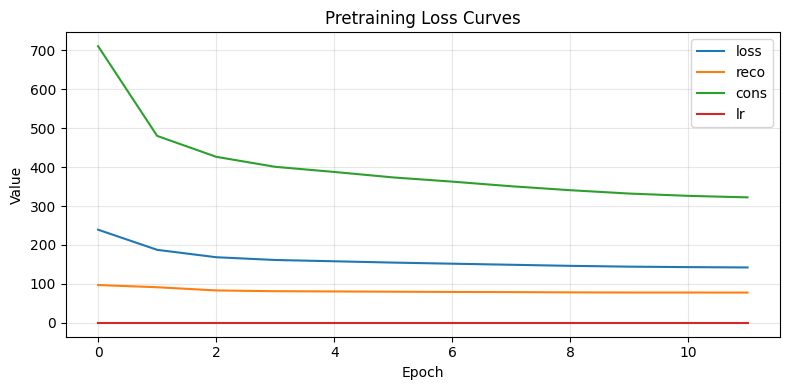

In [22]:
plot_curves(pre_hist, 'Pretraining Loss Curves')


In [23]:
@torch.no_grad()
def show_reco_examples(model, loader, cfg, n_events=2):
    model.eval()
    batch = next(iter(loader)); batch = to_device(batch, device)
    vis, tgt, rm, _ = build_mae_targets(batch['x'], batch['p4'], batch['mask'], cfg.MASK_RATIO)
    out = model(vis, batch['p4'], batch['mask'], mode='pretrain')

    names = list(cfg.PER_PARTICLE_FEATURES)
    for b in range(min(n_events, batch['x'].size(0))):
        idx = torch.where(rm[b])[0][:8]
        if len(idx) == 0: continue
        print(f'Event {b}, masked tokens shown: {len(idx)}')
        for fname in ['px','py','pz','E','pt']:
            j = names.index(fname)
            t = tgt[b, idx, j].detach().cpu().numpy()
            p = out['reco'][b, idx, j].detach().cpu().numpy()
            print(f'  {fname} true[:4]={np.round(t[:4],3)} pred[:4]={np.round(p[:4],3)}')

show_reco_examples(model, train_loader, cfg)


Event 0, masked tokens shown: 8
  px true[:4]=[44.036 12.868  6.095  5.208] pred[:4]=[1.261 1.102 1.017 0.948]
  py true[:4]=[-100.92   -30.734  -13.815  -11.905] pred[:4]=[-3.015 -2.414 -2.071 -1.917]
  pz true[:4]=[-91.994 -27.594 -11.458 -11.68 ] pred[:4]=[-2.758 -2.42  -2.248 -2.104]
  E true[:4]=[143.481  43.262  18.955  17.472] pred[:4]=[-7.634 -4.967 -4.111 -3.695]
  pt true[:4]=[110.109  33.319  15.099  12.995] pred[:4]=[109.512  31.153  13.979  12.043]
Event 1, masked tokens shown: 8
  px true[:4]=[26.879 21.775 13.972 16.054] pred[:4]=[1.456 1.459 1.74  1.442]
  py true[:4]=[-19.092  -9.922 -15.184  -8.177] pred[:4]=[-2.066 -2.174 -2.239 -2.082]
  pz true[:4]=[ -8.866 -21.852 -34.671 -17.716] pred[:4]=[-3.302 -3.378 -3.177 -3.397]
  E true[:4]=[34.14  32.405 40.35  25.268] pred[:4]=[ -7.53   -7.407 -10.428  -6.82 ]
  pt true[:4]=[32.969 23.929 20.634 18.016] pred[:4]=[32.973 25.389 19.613 18.311]


## 12. Fine-Tuning Run
Load pretrained or scratch weights and train on labeled JetClass data.

In [24]:
ckpt_path = Path('./checkpoints/hybrid_mae_pretrained.pt')
ckpt_path.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), ckpt_path)

ft_model = HybridLorentzParTMAE(cfg).to(device)
ft_model.load_state_dict(torch.load(ckpt_path, map_location=device), strict=False)

                                                                      
optf   = make_optimizer(ft_model, cfg, finetune_mode=True)                
schf   = make_scheduler(optf, cfg.FINETUNE_EPOCHS,
                        warmup_epochs=cfg.WARMUP_EPOCHS)                  
scalerf = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
early   = EarlyStopping(patience=cfg.EARLY_STOP_PATIENCE, mode='max')

best_path    = Path('./checkpoints/hybrid_mae_best_finetune.pt')
best_val_auc = -np.inf

ft_hist = {'train_loss': [], 'train_acc': [], 'val_acc': [],
           'val_auc_ovr': [], 'val_auc_ovo': [], 'lr': []}

for ep in range(cfg.FINETUNE_EPOCHS):
    tr = train_epoch_finetune(ft_model, train_loader, optf, scalerf,
                              device, cfg, class_weights=class_weights)
    va, *_ = eval_finetune(ft_model, val_loader, device, cfg)
    current_lr = schf.get_last_lr()[0]
    schf.step()

    val_auc = va['macro_auc_ovr']
    if np.isnan(val_auc):
        val_auc = va['accuracy']

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(ft_model.state_dict(), best_path)

    ft_hist['train_loss'].append(tr['loss'])
    ft_hist['train_acc'].append(tr['acc'])
    ft_hist['val_acc'].append(va['accuracy'])
    ft_hist['val_auc_ovr'].append(va['macro_auc_ovr'])
    ft_hist['val_auc_ovo'].append(va.get('macro_auc_ovo', np.nan))
    ft_hist['lr'].append(current_lr)

    print(f"[Finetune {ep+1:2d}/{cfg.FINETUNE_EPOCHS}]"
          f"  train_loss={tr['loss']:.4f}"
          f"  train_acc={tr['acc']:.4f}"
          f"  val_acc={va['accuracy']:.4f}"
          f"  val_auc={val_auc:.4f}"
          f"  lr={current_lr:.2e}")

    if early.step(val_auc):
        print(f"Early stopping at epoch {ep+1}."
              f" Best val_auc={best_val_auc:.4f}")
        break

if best_path.exists():
    ft_model.load_state_dict(
        torch.load(best_path, map_location=device), strict=False)
    print(f"Loaded best fine-tuned checkpoint (val_auc={best_val_auc:.4f})")


Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

[Finetune  1/20]  train_loss=1.8804  train_acc=0.3569  val_acc=0.4323  val_auc=0.8427  lr=1.00e-05


Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

[Finetune 19/20]  train_loss=1.3238  train_acc=0.6253  val_acc=0.6019  val_auc=0.9232  lr=7.97e-07


Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

[Finetune 20/20]  train_loss=1.3236  train_acc=0.6257  val_acc=0.6070  val_auc=0.9244  lr=3.50e-07
Loaded best fine-tuned checkpoint (val_auc=0.9244)


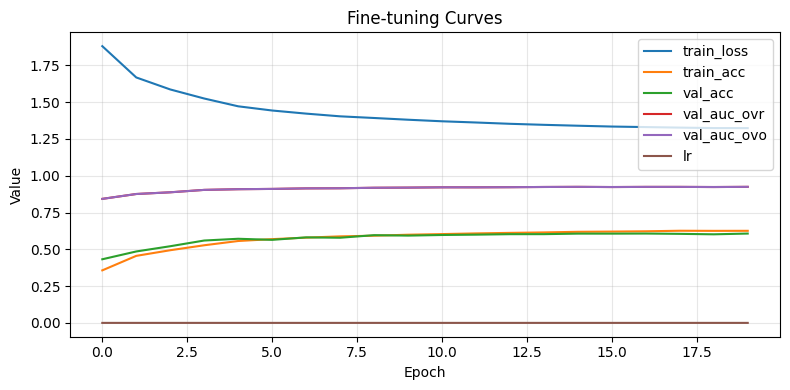

In [25]:
plot_curves(ft_hist, 'Fine-tuning Curves')


Eval:   0%|          | 0/625 [00:00<?, ?it/s]

  Overall accuracy : 0.6093
  Macro AUC (OvR) : 0.9267
  Macro AUC (OvO) : 0.9267

Per-class metrics (ParT-paper Table 1 format):
               AUC   Rej50%      Rej30%   Rej99%  Rej99.5%
class                                                     
HToBB       0.8683     13.7        32.1      1.5       1.4
HToCC       0.8715     17.0        54.8      1.4       1.3
HToGG       0.9183     26.8        70.3      1.9       1.8
HToWW2Q1L   0.9626    128.8       360.6      2.3       1.8
HToWW4Q     0.9356     37.2        99.9      2.0       1.8
TTBar       0.9782    116.8       562.2      3.6       2.5
TTBarLep    0.9891   9001.0 100000000.0      4.0       2.8
WToQQ       0.9205     26.3        60.4      1.7       1.5
ZJetsToNuNu 0.9323    147.4       817.6      1.4       1.2
ZToQQ       0.8902     15.1        34.4      1.7       1.4

Classification report (per-class precision/recall/F1):
              precision    recall  f1-score   support

       HToBB       0.45      0.41      0.43      10

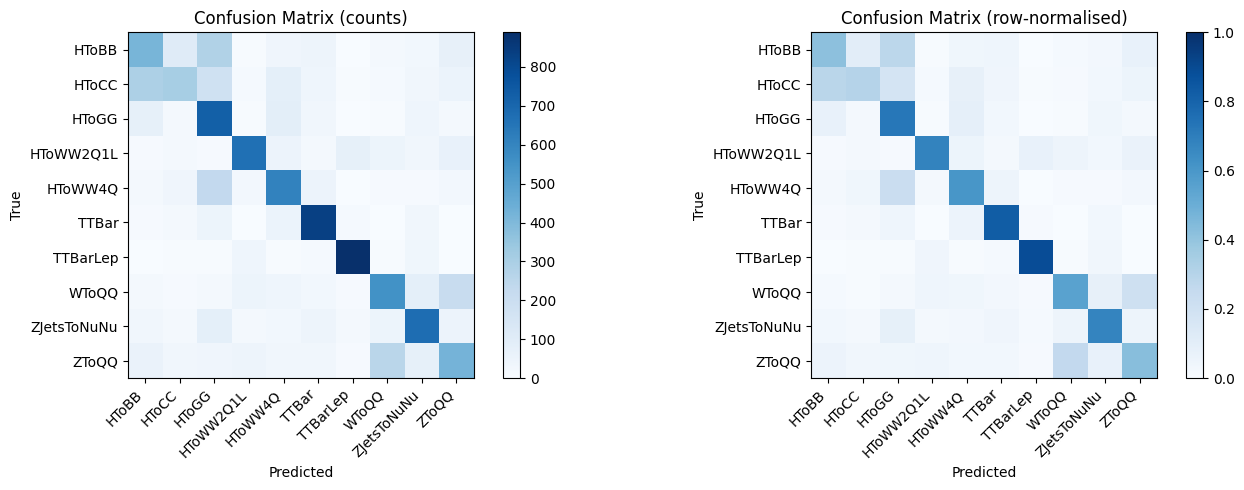

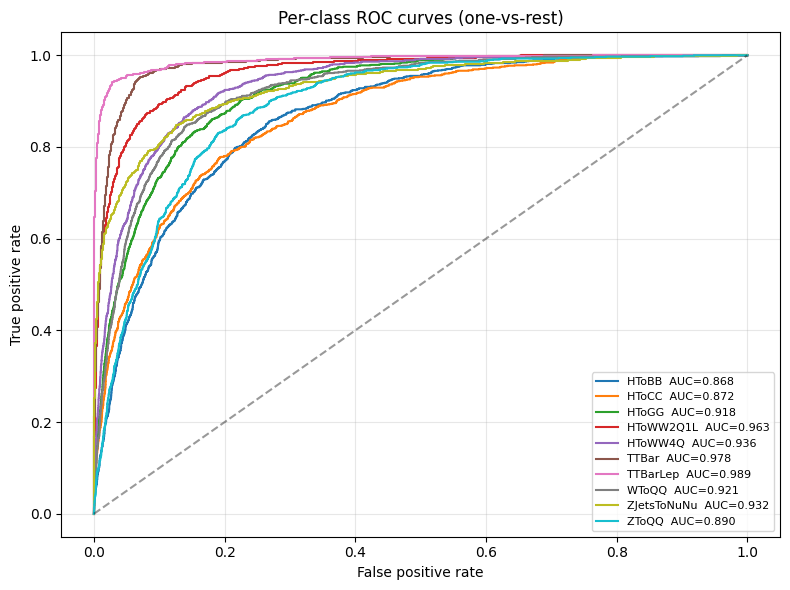


Background rejection at multiple signal efficiencies:
               AUC  Rej50%      Rej30%  Rej99%
class                                         
HToBB       0.8683    13.7        32.1     1.5
HToCC       0.8715    17.0        54.8     1.4
HToGG       0.9183    26.8        70.3     1.9
HToWW2Q1L   0.9626   128.8       360.6     2.3
HToWW4Q     0.9356    37.2        99.9     2.0
TTBar       0.9782   116.8       562.2     3.6
TTBarLep    0.9891  9001.0 100000000.0     4.0
WToQQ       0.9205    26.3        60.4     1.7
ZJetsToNuNu 0.9323   147.4       817.6     1.4
ZToQQ       0.8902    15.1        34.4     1.7


In [26]:
test_metrics, y_true, y_prob, y_pred = eval_finetune(
    ft_model, test_loader, device, cfg)

                                                                
per_class_df = print_physics_summary(
    test_metrics, y_true, y_prob, class_names, cfg)

print("\nClassification report (per-class precision/recall/F1):")
print(classification_report(y_true, y_pred,
                             target_names=[str(c) for c in class_names],
                             zero_division=0))

plot_confusion(y_true, y_pred, class_names)
plot_rocs(y_true, y_prob, class_names)

                                      
print("\nBackground rejection at multiple signal efficiencies:")
print(per_class_df[["AUC","Rej50%","Rej30%","Rej99%"]].to_string(
    float_format=lambda x: f"{x:.1f}" if x > 1 else f"{x:.4f}"))


## 13. Ablation Study
We compare architecture variants and quantify the contribution of pretraining.

In [27]:

def ablation_config(base: Config, name: str) -> Config:
    c = copy.deepcopy(base)
    if name == 'part_only':
        c.NUM_LAYERS_LORENTZ = 0
    elif name == 'lorentz_only':
        c.NUM_LAYERS_PART = 0
    elif name == 'naive_concat':
        c.USE_TOKEN_GATE = False; c.USE_EVENT_GATE = False
    elif name == 'gated_fusion':
        c.USE_TOKEN_GATE = True; c.USE_EVENT_GATE = True
    elif name == 'no_mass_aux':
        c.USE_AUX_MASS = False
    elif name == 'with_mass_aux':
        c.USE_AUX_MASS = True
    elif name in ['with_mae_pretrain','no_mae_pretrain']:
        pass
    else:
        raise ValueError(name)
    return c

def run_quick_ablations(cfg, train_loader, val_loader, names):
    rows = []
    for name in names:
        c = ablation_config(cfg, name)
        m = HybridLorentzParTMAE(c).to(device)
        o = make_optimizer(m, c)
        s = make_scheduler(o, 1, warmup_epochs=0)
        g = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)

        tr = train_epoch_finetune(m, train_loader, o, g, device, c, class_weights=class_weights)
        va, *_ = eval_finetune(m, val_loader, device, c)
        s.step()

        row = {'ablation': name, 'train_loss': tr['loss'], 'train_acc': tr['acc'], 'val_acc': va['accuracy'], 'val_auc': va['macro_auc_ovr']}
        rows.append(row)
        print(row)
    return pd.DataFrame(rows)

@torch.no_grad()
def evaluate_model_quick(model, loader, cfg):
    met, *_ = eval_finetune(model, loader, device, cfg)
    return {'val_acc': met['accuracy'], 'val_auc': met['macro_auc_ovr']}

def run_pretrain_vs_scratch_ablation(base_cfg, train_loader, val_loader, class_weights):
    c = copy.deepcopy(base_cfg)
    c.PRETRAIN_EPOCHS = 2
    c.FINETUNE_EPOCHS = 3

    feat_idx = {k:i for i,k in enumerate(c.PER_PARTICLE_FEATURES)}

    pretrained = HybridLorentzParTMAE(c).to(device)
    optp = make_optimizer(pretrained, c)
    scp = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
    shp = make_scheduler(optp, c.PRETRAIN_EPOCHS)
    for ep in range(c.PRETRAIN_EPOCHS):
        logs = train_epoch_pretrain(pretrained, train_loader, optp, scp, device, c, feat_idx)
        shp.step()
        print(f"[Ablation-Pretrain {ep+1}/{c.PRETRAIN_EPOCHS}] loss={logs['loss']:.4f} reco={logs['reco']:.4f} cons={logs['cons']:.4f}")

    optf_p = make_optimizer(pretrained, c)
    scf_p = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
    shf_p = make_scheduler(optf_p, c.FINETUNE_EPOCHS)
    for ep in range(c.FINETUNE_EPOCHS):
        tr_logs = train_epoch_finetune(pretrained, train_loader, optf_p, scf_p, device, c, class_weights=class_weights)
        shf_p.step()
        print(f"[Ablation-Finetune Pretrained {ep+1}/{c.FINETUNE_EPOCHS}] loss={tr_logs['loss']:.4f} acc={tr_logs['acc']:.4f}")
    m_pre = evaluate_model_quick(pretrained, val_loader, c)

    scratch = HybridLorentzParTMAE(c).to(device)
    optf_s = make_optimizer(scratch, c)
    scf_s = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)
    shf_s = make_scheduler(optf_s, c.FINETUNE_EPOCHS)
    for ep in range(c.FINETUNE_EPOCHS):
        tr_logs = train_epoch_finetune(scratch, train_loader, optf_s, scf_s, device, c, class_weights=class_weights)
        shf_s.step()
        print(f"[Ablation-Finetune Scratch {ep+1}/{c.FINETUNE_EPOCHS}] loss={tr_logs['loss']:.4f} acc={tr_logs['acc']:.4f}")
    m_scr = evaluate_model_quick(scratch, val_loader, c)

    rows = [
        {'ablation': 'with_mae_pretrain', 'val_acc': m_pre['val_acc'], 'val_auc': m_pre['val_auc']},
        {'ablation': 'no_mae_pretrain', 'val_acc': m_scr['val_acc'], 'val_auc': m_scr['val_auc']},
    ]
    return pd.DataFrame(rows)

ablation_names = ['part_only','lorentz_only','naive_concat','gated_fusion','no_mass_aux','with_mass_aux']
ablation_df = run_quick_ablations(cfg, train_loader, val_loader, ablation_names)
mae_ablation_df = run_pretrain_vs_scratch_ablation(cfg, train_loader, val_loader, class_weights)
ablation_all_df = pd.concat([ablation_df, mae_ablation_df], ignore_index=True)
ablation_all_df


Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

{'ablation': 'part_only', 'train_loss': 1.8079535228490828, 'train_acc': 0.3816375, 'val_acc': 0.4962, 'val_auc': 0.8789780783696234}


Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

...

[Ablation-Finetune Scratch 2/3] loss=1.5995 acc=0.4939


Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

[Ablation-Finetune Scratch 3/3] loss=1.4743 acc=0.5553


Eval:   0%|          | 0/625 [00:00<?, ?it/s]

,ablation,train_loss,train_acc,val_acc,val_auc
0,part_only,1.807954,0.381638,0.4962,0.878978
1,lorentz_only,1.873716,0.347775,0.4781,0.868345
2,naive_concat,1.778774,0.399462,0.5400,0.894797
3,gated_fusion,1.777332,0.400400,0.4823,0.879151
4,no_mass_aux,1.792322,0.390813,0.5209,0.888877
5,with_mass_aux,5.850222,0.303725,0.4011,0.838749
6,with_mae_pretrain,NaN,NaN,0.5855,0.916614
7,no_mae_pretrain,NaN,NaN,0.5829,0.913572


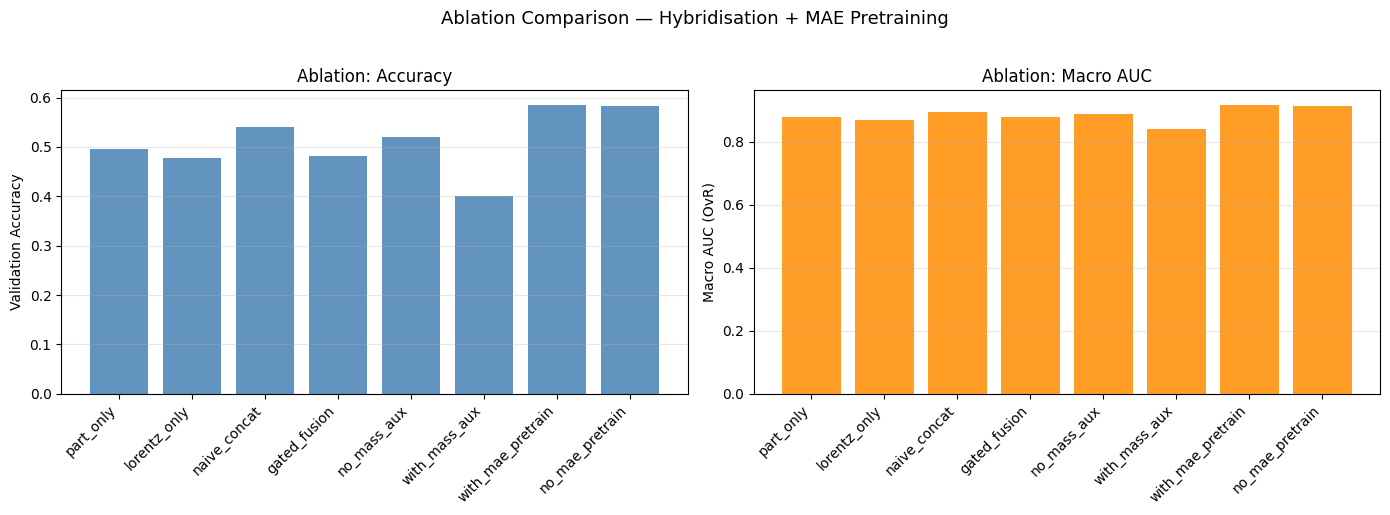

         ablation  train_loss  train_acc  val_acc  val_auc
        part_only    1.807954   0.381638   0.4962 0.878978
     lorentz_only    1.873716   0.347775   0.4781 0.868345
     naive_concat    1.778774   0.399462   0.5400 0.894797
     gated_fusion    1.777332   0.400400   0.4823 0.879151
      no_mass_aux    1.792322   0.390813   0.5209 0.888877
    with_mass_aux    5.850222   0.303725   0.4011 0.838749
with_mae_pretrain         NaN        NaN   0.5855 0.916614
  no_mae_pretrain         NaN        NaN   0.5829 0.913572


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

                    
axes[0].bar(ablation_all_df['ablation'], ablation_all_df['val_acc'],
            color='steelblue', alpha=0.85)
axes[0].set_xticks(range(len(ablation_all_df)))
axes[0].set_xticklabels(ablation_all_df['ablation'], rotation=45, ha='right')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Ablation: Accuracy')
axes[0].grid(axis='y', alpha=0.3)

               
axes[1].bar(ablation_all_df['ablation'],
            ablation_all_df['val_auc'].fillna(0),
            color='darkorange', alpha=0.85)
axes[1].set_xticks(range(len(ablation_all_df)))
axes[1].set_xticklabels(ablation_all_df['ablation'], rotation=45, ha='right')
axes[1].set_ylabel('Macro AUC (OvR)')
axes[1].set_title('Ablation: Macro AUC')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Ablation Comparison — Hybridisation + MAE Pretraining',
             fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
print(ablation_all_df.to_string(index=False))


### Multi-seed Evaluation
Experiments are repeated across random seeds to report mean and variability.

In [29]:
def run_multiseed_eval(base_cfg: Config, train_loader, val_loader, test_loader,
                       class_weights, n_seeds: int = 3,
                       pretrained_state: Optional[dict] = None) -> pd.DataFrame:
    rows = []
    for seed in range(42, 42 + n_seeds):
        seed_everything(seed)
        c = copy.deepcopy(base_cfg)
        c.SEED = seed
        c.FINETUNE_EPOCHS = min(c.FINETUNE_EPOCHS, 10)                   

        m = HybridLorentzParTMAE(c).to(device)
        if pretrained_state is not None:
            m.load_state_dict(pretrained_state, strict=False)

        opt_s = make_optimizer(m, c, finetune_mode=(pretrained_state is not None))
        sch_s = make_scheduler(opt_s, c.FINETUNE_EPOCHS, c.WARMUP_EPOCHS)
        sc_s  = torch.amp.GradScaler(device=device.type, enabled=amp_enabled)

        best_auc, best_state = -np.inf, None
        for ep in range(c.FINETUNE_EPOCHS):
            train_epoch_finetune(m, train_loader, opt_s, sc_s, device, c,
                                 class_weights=class_weights)
            va, *_ = eval_finetune(m, val_loader, device, c)
            sch_s.step()
            auc_v = va['macro_auc_ovr'] if not np.isnan(va['macro_auc_ovr']) else va['accuracy']
            if auc_v > best_auc:
                best_auc = auc_v
                best_state = copy.deepcopy(m.state_dict())

        if best_state is not None:
            m.load_state_dict(best_state)
        te, *_ = eval_finetune(m, test_loader, device, c)
        rows.append({
            'seed': seed,
            'test_acc': te['accuracy'],
            'test_auc_ovr': te['macro_auc_ovr'],
        })
        print(f"  seed={seed}  acc={te['accuracy']:.4f}"
              f"  auc={te['macro_auc_ovr']:.4f}")

    df = pd.DataFrame(rows)
    return df


def summarise_seeds(df: pd.DataFrame, label: str):
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    for col in ['test_acc', 'test_auc_ovr']:
        if col in df.columns:
            print(f"  {col}: {df[col].mean():.4f} ± {df[col].std():.4f}")
    print(f"{'='*50}")


N_SEEDS = 3                                                 

print("Running multi-seed: pretrained weights...")
pretrained_weights = torch.load(best_path, map_location='cpu') if best_path.exists() else None
df_pretrained = run_multiseed_eval(
    cfg, train_loader, val_loader, test_loader,
    class_weights, n_seeds=N_SEEDS,
    pretrained_state=pretrained_weights)

print("\nRunning multi-seed: from scratch...")
df_scratch = run_multiseed_eval(
    cfg, train_loader, val_loader, test_loader,
    class_weights, n_seeds=N_SEEDS,
    pretrained_state=None)

summarise_seeds(df_pretrained, "Pretrained (MAE → finetune)")
summarise_seeds(df_scratch,    "From scratch")

comparison_df = pd.DataFrame({
    'mode':    ['pretrained', 'scratch'],
    'acc_mean': [df_pretrained['test_acc'].mean(),  df_scratch['test_acc'].mean()],
    'acc_std':  [df_pretrained['test_acc'].std(),   df_scratch['test_acc'].std()],
    'auc_mean': [df_pretrained['test_auc_ovr'].mean(), df_scratch['test_auc_ovr'].mean()],
    'auc_std':  [df_pretrained['test_auc_ovr'].std(),  df_scratch['test_auc_ovr'].std()],
})
print("\nSummary comparison:")
print(comparison_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


Running multi-seed: pretrained weights...


Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

Finetune:   0%|          | 0/5000 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

  seed=44  acc=0.6397  auc=0.9341

  Pretrained (MAE → finetune)
  test_acc: 0.6240 ± 0.0009
  test_auc_ovr: 0.9305 ± 0.0005

  From scratch
  test_acc: 0.6412 ± 0.0031
  test_auc_ovr: 0.9344 ± 0.0008

Summary comparison:
      mode  acc_mean  acc_std  auc_mean  auc_std
pretrained    0.6240   0.0009    0.9305   0.0005
   scratch    0.6412   0.0031    0.9344   0.0008


## 14. Mass Regression
An optional auxiliary head predicts jet mass jointly with class labels.

Event gate summary:
 count    48.000000
mean      0.994201
std       0.039060
min       0.729268
25%       0.999923
50%       1.000000
75%       1.000000
max       1.000000
dtype: float64
Token gate summary:
 count    48.000000
mean      0.498352
std       0.009307
min       0.476307
25%       0.494475
50%       0.500059
75%       0.503289
max       0.523204
dtype: float64


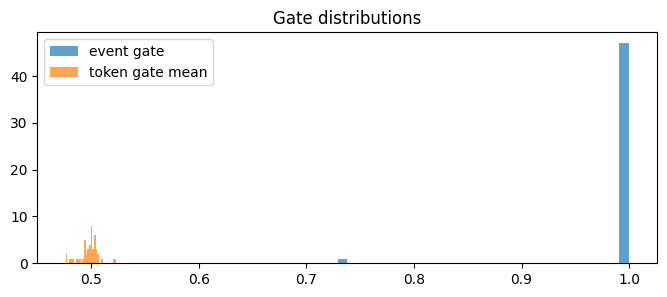

Mean gate by class:
   event_gate  token_gate
y                        
0    0.999972    0.503358
2    0.999339    0.506838
3    1.000000    0.499007
4    0.999677    0.500438
5    0.945693    0.492962
6    0.999988    0.487437
7    1.000000    0.501553
8    1.000000    0.504625


In [30]:
@torch.no_grad()
def inspect_gates(model, loader, n_batches=3):
    model.eval()
    ge, gt, yy = [], [], []
    for i, batch in enumerate(loader):
        if i >= n_batches: break
        batch = to_device(batch, device)
        out = model(batch['x'], batch['p4'], batch['mask'], mode='finetune')
        ge.append(out['g_evt'].squeeze(-1).cpu().numpy())
        gt.append(out['g_tok'].mean(dim=(1,2)).cpu().numpy())
        yy.append(batch['y'].cpu().numpy())

    ge = np.concatenate(ge); gt = np.concatenate(gt); yy = np.concatenate(yy)
    print('Event gate summary:\n', pd.Series(ge).describe())
    print('Token gate summary:\n', pd.Series(gt).describe())

    plt.figure(figsize=(8,3))
    plt.hist(ge, bins=30, alpha=0.7, label='event gate')
    plt.hist(gt, bins=30, alpha=0.7, label='token gate mean')
    plt.legend(); plt.title('Gate distributions'); plt.show()

    df = pd.DataFrame({'y': yy, 'event_gate': ge, 'token_gate': gt})
    print('Mean gate by class:')
    print(df.groupby('y')[['event_gate','token_gate']].mean())

inspect_gates(ft_model, test_loader)


count    574.000000
mean       0.000153
std        0.000200
min        0.000002
25%        0.000029
50%        0.000079
75%        0.000198
max        0.001354
dtype: float64


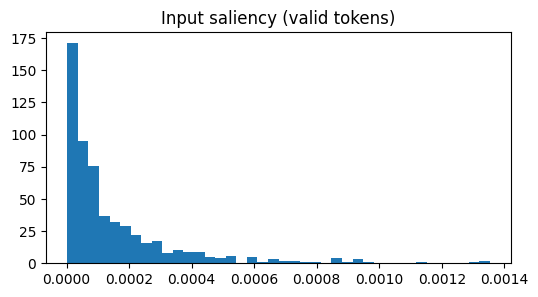

In [31]:
def simple_saliency(model, batch):
    model.eval()
    x = batch['x'].to(device).clone().detach().requires_grad_(True)
    p4, mask, y = batch['p4'].to(device), batch['mask'].to(device), batch['y'].to(device)

    out = model(x, p4, mask, mode='finetune')
    loss = F.cross_entropy(out['logits'], y)
    loss.backward()

    sal = x.grad.abs().mean(dim=-1).detach().cpu().numpy()
    vm = batch['mask'].numpy() > 0.5
    vals = sal[vm]
    print(pd.Series(vals).describe())
    plt.figure(figsize=(6,3)); plt.hist(vals, bins=40)
    plt.title('Input saliency (valid tokens)'); plt.show()

batch0 = next(iter(test_loader))
simple_saliency(ft_model, batch0)


In [32]:
@torch.no_grad()
def reconstruction_failure_cases(model, loader, cfg, topk=5):
    model.eval()
    errs = []
    for batch in loader:
        batch = to_device(batch, device)
        vis, tgt, rm, _ = build_mae_targets(batch['x'], batch['p4'], batch['mask'], cfg.MASK_RATIO)
        out = model(vis, batch['p4'], batch['mask'], mode='pretrain')
        per_evt = (((out['reco'] - tgt)**2).mean(dim=-1) * rm.float()).sum(dim=1)
        errs.extend(per_evt.cpu().numpy().tolist())

    errs = np.array(errs)
    idx = np.argsort(-errs)[:topk]
    print('Top failure indices:', idx)
    print('Errors:', errs[idx])

reconstruction_failure_cases(ft_model, test_loader, cfg)


Top failure indices: [ 621 6990 7892 8461 4301]
Errors: [752473.625   545766.25    461383.09375 415467.84375 408640.96875]


## 15. Final Results
This section summarizes key quantitative outcomes and practical takeaways.

In [33]:
                                                                             
try:
    _cfg_ready   = isinstance(cfg, Config)
    _model_ready = 'ft_model' in dir() and ft_model is not None
except NameError:
    _cfg_ready = _model_ready = False

if not _cfg_ready:
    print("[INFO] Run all cells from the top first (cfg not defined yet).")
elif not _model_ready:
    print("[INFO] Run the fine-tuning section first (ft_model not defined yet).")
elif not cfg.USE_AUX_MASS:
    print("[INFO] Mass regression is disabled.")
    print("       Set  cfg.USE_AUX_MASS = True  before the pretraining run")
    print("       and re-run from Section 11 to activate it.")
else:
                                                                              
    test_metrics_mass, _yt, _yp_prob, _yp = eval_finetune(
        ft_model, test_loader, device, cfg)

    ft_model.eval()
    true_m, pred_m = [], []
    with torch.no_grad():
        for _batch in test_loader:
            _batch = to_device(_batch, device)
            _out   = ft_model(_batch['x'], _batch['p4'], _batch['mask'],
                               mode='multitask')
            true_m.extend(_batch['mass'].cpu().numpy().tolist())
            if 'mass_pred' in _out:
                pred_m.extend(_out['mass_pred'].cpu().numpy().tolist())

    if not pred_m:
        print("[WARN] No mass predictions found. "
              "Ensure USE_AUX_MASS=True was set before training.")
    else:
        true_m = np.array(true_m, dtype=np.float32)
        pred_m = np.array(pred_m, dtype=np.float32)

                                                                             
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        axes[0].scatter(true_m, pred_m, s=2, alpha=0.25, c='steelblue')
        _lim = [min(true_m.min(), pred_m.min()),
                max(true_m.max(), pred_m.max())]
        axes[0].plot(_lim, _lim, 'r--', lw=1.2, label='ideal')
        axes[0].set_xlabel('True mass [GeV]')
        axes[0].set_ylabel('Predicted mass [GeV]')
        mae_v  = test_metrics_mass.get('mass_mae',  float('nan'))
        rmse_v = test_metrics_mass.get('mass_rmse', float('nan'))
        axes[0].set_title(f"Mass regression  MAE={mae_v:.3f} GeV")
        axes[0].legend(fontsize=8)
        axes[0].grid(alpha=0.3)

                                                                              
        residual = pred_m - true_m
        axes[1].hist(residual, bins=60, density=True,
                     color='darkorange', alpha=0.8)
        axes[1].axvline(0, color='r', lw=1.2, ls='--')
        axes[1].set_xlabel('Residual  (pred − true) [GeV]')
        axes[1].set_title(f"Residual  μ={residual.mean():.2f}"
                          f"  σ={residual.std():.2f}")
        axes[1].grid(alpha=0.3)

                                                                              
        eps      = 1e-3
        rel_err  = np.abs(residual) / (true_m + eps)
        axes[2].scatter(true_m, rel_err, s=2, alpha=0.2, c='seagreen')
        axes[2].set_xlabel('True mass [GeV]')
        axes[2].set_ylabel('|pred − true| / true')
        axes[2].set_title('Relative error vs true mass')
        axes[2].set_ylim(0, min(rel_err.quantile(0.99)
                                if hasattr(rel_err, 'quantile')
                                else np.percentile(rel_err, 99), 2.0))
        axes[2].grid(alpha=0.3)

        plt.suptitle('Mass Regression Evaluation', fontsize=13, y=1.02)
        plt.tight_layout()
        plt.show()

        print(f"Mass MAE  : {mae_v:.4f} GeV")
        print(f"Mass RMSE : {rmse_v:.4f} GeV")
        print(f"Residual  : mean={residual.mean():.4f}  std={residual.std():.4f}")


[INFO] Mass regression is disabled.
       Set  cfg.USE_AUX_MASS = True  before the pretraining run
       and re-run from Section 11 to activate it.


In [34]:
print(json.dumps(asdict(cfg), indent=2))

{
  "DATA_ROOT": "C:\\Users\\Rahul\\Desktop\\AA Gsoc'26 p-3\\datasets\\JetClass",
  "MAX_PARTICLES": 128,
  "NUM_CLASSES": 10,
  "BATCH_SIZE": 16,
  "NUM_WORKERS": 0,
  "PRETRAIN_EPOCHS": 12,
  "FINETUNE_EPOCHS": 20,
  "LEARNING_RATE": 0.0002,
  "WEIGHT_DECAY": 0.0001,
  "MASK_RATIO": 0.4,
  "WARMUP_EPOCHS": 2,
  "LABEL_SMOOTHING": 0.1,
  "USE_BIASED_MASK": true,
  "BACKBONE_LR_FACTOR": 0.1,
  "USE_AUX_MASS": false,
  "USE_CLASS_WEIGHTS": true,
  "USE_MIXED_PRECISION": true,
  "QUICK_DEMO_MODE": false,
  "QUICK_MAX_EVENTS_PER_FILE": 1000,
  "FULL_MAX_EVENTS_PER_FILE": 2500,
  "SAMPLE_SIZE_LIMIT": 100000,
  "ENFORCE_STRICT_100K_WHEN_AVAILABLE": true,
  "SAMPLING_SEED": 42,
  "NUM_TRAIN_FILES": null,
  "NUM_VAL_FILES": null,
  "NUM_TEST_FILES": null,
  "PER_PARTICLE_FEATURES": [
    "px",
    "py",
    "pz",
    "E",
    "pt",
    "eta",
    "phi",
    "charge",
    "valid_mask"
  ],
  "PAIRWISE_FEATURES": [
    "lnDelta",
    "lnkT",
    "lnz",
    "lnm2"
  ],
  "SCALE_FEATURES": [
    

## 16. Notes
The notebook follows a clear flow: setup, data, features, model, training, and evaluation.
Use it as a concise experiment record for the hybrid JetClass pipeline.